In [ ]:
pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is stil

In [ ]:
!pip install pandas==2.2.2 numpy scipy scikit-learn

In [ ]:
from autogluon.tabular import TabularDataset, TabularPredictor
import time
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

print("AutoGluon dan dependensi berhasil diimpor.")

AutoGluon dan dependensi berhasil diimpor.


In [ ]:
student_data = pd.read_csv('./Students Performance Dataset.csv')

student_data.drop(columns=['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Total_Score', 'Attendance (%)',
                           'Final_Score', 'Projects_Score'], inplace=True)
student_data.shape

(5000, 15)

In [ ]:
student_data.head()

,Gender,Age,Department,Midterm_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,Female,22,Mathematics,40.61,73.69,53.17,73.4,F,10.3,Yes,No,Master's,Medium,1,5.9
1,Male,18,Business,57.27,74.23,98.23,88.0,B,27.1,No,No,High School,Low,4,4.3
2,Male,24,Engineering,41.84,85.85,50.00,4.7,D,12.4,Yes,No,High School,Low,9,6.1
3,Female,24,Engineering,45.65,68.10,66.27,4.2,F,25.5,No,Yes,High School,Low,8,4.9
4,Female,23,CS,53.13,67.66,83.98,64.3,C,13.3,Yes,No,Master's,Medium,6,4.5


In [ ]:
student_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Gender                      5000 non-null   object 
 1   Age                         5000 non-null   int64  
 2   Department                  5000 non-null   object 
 3   Midterm_Score               5000 non-null   float64
 4   Assignments_Avg             5000 non-null   float64
 5   Quizzes_Avg                 5000 non-null   float64
 6   Participation_Score         5000 non-null   float64
 7   Grade                       5000 non-null   object 
 8   Study_Hours_per_Week        5000 non-null   float64
 9   Extracurricular_Activities  5000 non-null   object 
 10  Internet_Access_at_Home     5000 non-null   object 
 11  Parent_Education_Level      3975 non-null   object 
 12  Family_Income_Level         5000 non-null   object 
 13  Stress_Level (1-10)         5000 

In [ ]:
student_data = student_data[student_data['Grade'] != 'A']

In [ ]:
student_data['Grade'].value_counts()

,count
Grade,
C,2307
D,1760
B,638
F,279


In [ ]:
student_data.describe()

,Age,Midterm_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night
count,4984.000000,4984.000000,4984.000000,4984.000000,4984.000000,4984.000000,4984.000000,4984.000000
mean,21.047753,70.636906,74.908740,74.797145,49.877769,17.517255,5.506421,6.513102
std,1.990981,17.421557,14.394863,14.422735,28.977807,7.196548,2.887127,1.446494
min,18.000000,40.000000,50.000000,50.000000,0.000000,5.000000,1.000000,4.000000
25%,19.000000,55.647500,62.327500,62.337500,25.000000,11.500000,3.000000,5.300000
50%,21.000000,70.730000,75.005000,74.820000,49.400000,17.400000,6.000000,6.500000
75%,23.000000,85.640000,87.230000,87.272500,75.425000,23.700000,8.000000,7.800000
max,24.000000,99.990000,99.990000,99.990000,100.000000,30.000000,10.000000,9.000000


In [ ]:
#cek missing value
student_data.isnull().sum()/student_data.shape[0]*100

,0
Gender,0.000000
Age,0.000000
Department,0.000000
Midterm_Score,0.000000
Assignments_Avg,0.000000
Quizzes_Avg,0.000000
Participation_Score,0.000000
Grade,0.000000
Study_Hours_per_Week,0.000000
Extracurricular_Activities,0.000000


In [ ]:
from sklearn.model_selection import train_test_split

X = student_data.drop(columns=['Grade'])
y = student_data['Grade']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=42,
    stratify=y
)

print("=" * 50)
print("HASIL TRAIN-TEST SPLIT")
print("=" * 50)

print(f"Jumlah data training : {len(X_train)}")
print(f"Jumlah data testing  : {len(X_test)}")

print(f"\nShape X_train : {X_train.shape}")
print(f"Shape X_test  : {X_test.shape}")

print("\nDistribusi Grade pada Dataset Asli")
print(y.value_counts(normalize=True).sort_index())

print("\nDistribusi Grade pada Training Set")
print(y_train.value_counts(normalize=True).sort_index())

print("\nDistribusi Grade pada Testing Set")
print(y_test.value_counts(normalize=True).sort_index())

HASIL TRAIN-TEST SPLIT
Jumlah data training : 3987
Jumlah data testing  : 997

Shape X_train : (3987, 14)
Shape X_test  : (997, 14)

Distribusi Grade pada Dataset Asli
Grade
B    0.128010
C    0.462881
D    0.353130
F    0.055979
Name: proportion, dtype: float64

Distribusi Grade pada Training Set
Grade
B    0.127916
C    0.463005
D    0.353148
F    0.055932
Name: proportion, dtype: float64

Distribusi Grade pada Testing Set
Grade
B    0.128385
C    0.462387
D    0.353059
F    0.056169
Name: proportion, dtype: float64


In [ ]:
import numpy as np
def apply_feature_engineering(data):
    student_data_engineered = data.copy()

    weekly_sleep = (student_data_engineered['Sleep_Hours_per_Night'] * 7)
    # Ide 1: Rasio Belajar per Jam Tidur (Mendeteksi anak yang burnout)
    # Ditambah 0.1 agar tidak ada error pembagian dengan 0
    student_data_engineered['Study_Sleep_Ratio'] = student_data_engineered['Study_Hours_per_Week'] / (weekly_sleep + 0.1)


    # Ide 2: Indeks Sosial Ekonomi (SES Score)
    # Kita buat sistem bobot/skoring manual.
    # Semakin mapan finansial dan pendidikannya, semakin tinggi skornya.
    income_weights = {'Low': 1, 'Medium': 2, 'High': 3}
    edu_weights = {'High School': 1, "Bachelor's": 2, "Master's": 3, 'PhD': 4, 'Unknown': 0}

    # Lakukan mapping (jika ada nilai kosong/Unknown, otomatis diisi bobot terendah/0)
    income_score = student_data_engineered['Family_Income_Level'].map(income_weights).fillna(0)
    edu_score = student_data_engineered['Parent_Education_Level'].map(edu_weights).fillna(0)

    # Gabungkan menjadi satu kolom kekuatan sosial ekonomi
    student_data_engineered['SES_Score'] = income_score + edu_score


    # Ide 3: Total Beban Waktu (Time Load) & Titik Patah
    # Gunakan np.where: Jika 'Yes' beri 10 jam, jika 'No' beri 0 jam
    extra_hours = np.where(student_data_engineered['Extracurricular_Activities'] == 'Yes', 10, 0)

    # Kalkulasi total beban akademik per minggu
    student_data_engineered['Total_Weekly_Load'] = student_data_engineered['Study_Hours_per_Week'] + extra_hours

    # Rasio Beban Total vs Istirahat (Ini adalah metrik "Titik Patah" yang lebih akurat)
    student_data_engineered['Load_Sleep_Ratio'] = student_data_engineered['Total_Weekly_Load'] / (weekly_sleep + 0.1)

    return student_data_engineered

X_train = apply_feature_engineering(X_train)
X_test = apply_feature_engineering(X_test)

In [ ]:
from imblearn.over_sampling import RandomOverSampler


ros = RandomOverSampler(random_state=42)

print("Shape of X_train before oversampling:", X_train.shape)
print("Shape of y_train before oversampling:", y_train.shape)

X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

print("Shape of X_train_ros after oversampling:", X_train_ros.shape)
print("Shape of y_train_ros after oversampling:", y_train_ros.shape)

print("\nClass distribution of y_train_ros after oversampling:")
import pandas as pd
print(pd.Series(y_train_ros).value_counts())

Shape of X_train before oversampling: (3987, 18)
Shape of y_train before oversampling: (3987,)
Shape of X_train_ros after oversampling: (7384, 18)
Shape of y_train_ros after oversampling: (7384,)

Class distribution of y_train_ros after oversampling:
Grade
B    1846
D    1846
C    1846
F    1846
Name: count, dtype: int64


In [ ]:
import pandas as pd
import time
from autogluon.tabular import TabularPredictor


train_data = pd.concat([X_train_ros.copy(), y_train_ros.copy()], axis=1)
test_data = pd.concat([X_test.copy(), y_test.copy()], axis=1)

print(f"Shape training data AutoGluon: {train_data.shape}")
print(f"Shape test data AutoGluon: {test_data.shape}")


target_column = 'Grade'

print("Lagi training AutoGluon...")

start_time = time.time()
predictor = TabularPredictor(
    label=target_column,
    eval_metric='f1_macro',
    path='AutogluonModels_new'
).fit(
    train_data,
    time_limit=900,
    presets='best_quality'

)
end_time = time.time()

print(f"\nWaktu training AutoGluon: {end_time - start_time:.2f} detik")
print("\nRingkasan pelatihan AutoGluon:")
predictor.leaderboard(test_data, silent=True)

Verbosity: 2 (Standard Logging)


Shape training data AutoGluon: (7384, 19)
Shape test data AutoGluon: (997, 19)
Lagi training AutoGluon...


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       10.98 GB / 12.67 GB (86.7%)
Disk Space Avail:   75.74 GB / 107.72 GB (70.3%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will 


Waktu training AutoGluon: 946.92 detik

Ringkasan pelatihan AutoGluon:


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMXT_BAG_L1,0.341920,0.805408,f1_macro,13.143505,20.023731,184.988034,13.143505,20.023731,184.988034,1,True,2
1,WeightedEnsemble_L2,0.341920,0.805408,f1_macro,13.146062,20.031130,185.528632,0.002558,0.007399,0.540597,2,True,4
2,LightGBM_BAG_L1,0.327025,0.803127,f1_macro,2.876005,4.232262,82.496058,2.876005,4.232262,82.496058,1,True,3
3,NeuralNetFastAI_BAG_L1,0.309266,0.742282,f1_macro,0.957150,0.509654,137.072698,0.957150,0.509654,137.072698,1,True,1
4,LightGBMXT_BAG_L2,0.278096,0.843606,f1_macro,17.088920,24.914387,442.954037,0.112259,0.148739,38.397247,2,True,6
5,WeightedEnsemble_L3,0.275795,0.847578,f1_macro,17.405420,25.440103,592.160313,0.002802,0.007069,0.839006,3,True,7
6,NeuralNetFastAI_BAG_L2,0.275172,0.845508,f1_macro,17.290359,25.284295,552.924061,0.313698,0.518647,148.367270,2,True,5



=== Prediksi dengan AutoGluon ===
Prediksi selesai.

=== Evaluasi Model AutoGluon (Classification Report) ===
              precision    recall  f1-score   support

           B       0.20      0.02      0.03       128
           C       0.50      0.75      0.60       461
           D       0.48      0.40      0.44       352
           F       0.50      0.02      0.03        56

    accuracy                           0.49       997
   macro avg       0.42      0.30      0.28       997
weighted avg       0.45      0.49      0.44       997


=== Confusion Matrix (AutoGluon) ===


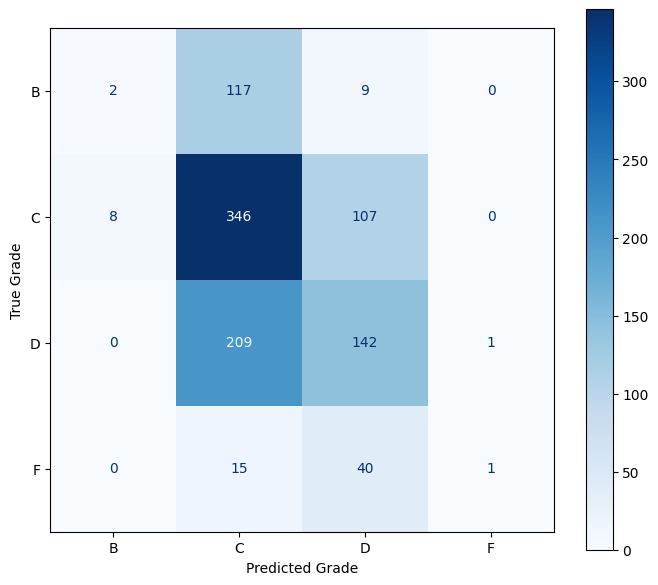

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

print("\n=== Prediksi dengan AutoGluon ===")


y_pred = predictor.predict(X_test)

print("Prediksi selesai.")

print("\n=== Evaluasi Model AutoGluon (Classification Report) ===")
print(classification_report(y_test, y_pred))

print("\n=== Confusion Matrix (AutoGluon) ===")

cm = confusion_matrix(y_test, y_pred, labels=predictor.class_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=predictor.class_labels)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')

ax.set_xlabel('Predicted Grade')
ax.set_ylabel('True Grade')
plt.tight_layout()
plt.savefig('Confusion_Matrix_Autogluon_With_F.pdf')
plt.show()

Computing feature importance via permutation shuffling for 18 features using 997 rows with 5 shuffle sets...



=== ANALISIS FEATURE IMPORTANCE (AutoGluon) ===


	2896.47s	= Expected runtime (579.29s per shuffle set)
	1150.86s	= Actual runtime (Completed 5 of 5 shuffle sets)



Ranking Fitur Paling Berpengaruh Terhadap GRADE (AutoGluon):
                            importance    stddev   p_value  n  p99_high   p99_low
Assignments_Avg               0.018954  0.010278  0.007285  5  0.040117 -0.002209
Midterm_Score                 0.014552  0.008816  0.010503  5  0.032705 -0.003601
Total_Weekly_Load             0.008517  0.002980  0.001538  5  0.014653  0.002381
Participation_Score           0.006603  0.005183  0.023236  5  0.017275 -0.004070
Study_Hours_per_Week          0.005810  0.003343  0.008878  5  0.012694 -0.001074
Sleep_Hours_per_Night         0.005617  0.007544  0.085631  5  0.021150 -0.009916
Load_Sleep_Ratio              0.003214  0.008422  0.220806  5  0.020555 -0.014128
Study_Sleep_Ratio             0.002992  0.005531  0.146517  5  0.014379 -0.008396
Quizzes_Avg                   0.000818  0.012452  0.445188  5  0.026456 -0.024821
Parent_Education_Level        0.000271  0.002697  0.416743  5  0.005824 -0.005283
Extracurricular_Activities   -0.0005

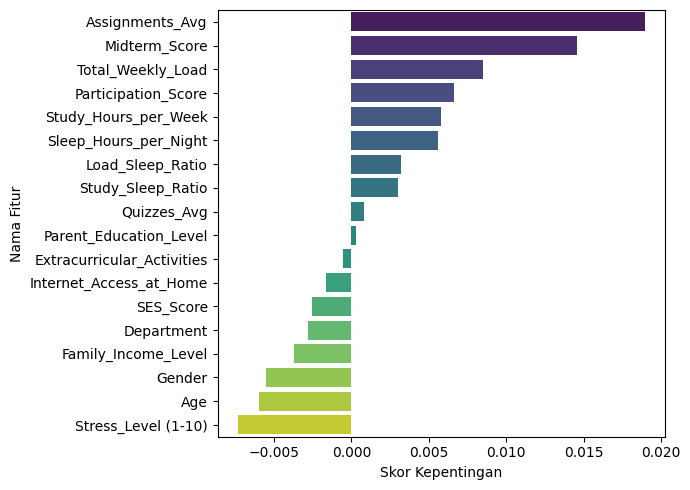

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n=== ANALISIS FEATURE IMPORTANCE (AutoGluon) ===")

try:

    feature_importance_student_data = predictor.feature_importance(
        data=test_data,
        subsample_size=5000
    )


    importance_sorted = feature_importance_student_data.sort_values(by='importance', ascending=False)
    print("\nRanking Fitur Paling Berpengaruh Terhadap GRADE (AutoGluon):")
    print(importance_sorted.to_string())


    importance_sorted['feature'] = importance_sorted.index
    importance_sorted = importance_sorted.reset_index(drop=True)


    plt.figure(figsize=(7, 5))
    sns.barplot(
        data=importance_sorted,
        x='importance',
        y='feature',
        palette='viridis',
        hue='feature',
        legend=False
    )

    plt.xlabel('Skor Kepentingan')
    plt.ylabel('Nama Fitur')
    plt.tight_layout()
    plt.savefig('Feature_Importance_Autogluon_With_F.pdf')
    plt.show()

except Exception as e:
    print(f"Gagal menghitung feature importance atau membuat plot: {e}")
    print("Pastikan 'predictor_ag' sudah dilatih dan 'target_column_ag' benar.")